In [1]:
import pandas as pd
import seaborn as sns
import path_config
sns.set_theme() 

In [2]:
from lib.utils_plotting import print_avg_results, results_file, get_mae

results,results_w_regions = results_file("test", selected_months=[3,6,9,12])
results_val, results_w_regions_val = results_file("val", selected_months=[3,6,9,12])
	
from lib.utils_plotting import convex_ensemble, simple_ensemble

# 2-model ensembles
m1, m2 = "prithvi_pretrained_multiscale_crops_conv3d_1.0", "shallow_transformer_pixels_1.0"
base_methods = [m1, m2]

simple_key = f"Simple Ensemble {', '.join(base_methods)}"
simple_ensemble(
	base_methods,
	results_w_regions_val,
	results_w_regions,
	out_name=simple_key,
)

results_mae = {"HLStile": [], "Date": [], "MAE": [], "Method": [], "SiteID": [], "years": []}
for tile, siteid, year in results_w_regions["shallow_transformer_pixels_1.0_test"][["HLStile", "SiteID", "years"]].drop_duplicates().values:
    for key in results_w_regions.keys(): 
        results_mae = get_mae(results_w_regions[key], tile, siteid, year, results_mae, key)

results_mae_df = pd.DataFrame(results_mae)

Simple ensemble weights (Simple Ensemble prithvi_pretrained_multiscale_crops_conv3d_1.0, shallow_transformer_pixels_1.0):
  G_pred_DOY: prithvi_pretrained_multiscale_crops_conv3d_1.0: 0.542  shallow_transformer_pixels_1.0: 0.458
  M_pred_DOY: prithvi_pretrained_multiscale_crops_conv3d_1.0: 0.628  shallow_transformer_pixels_1.0: 0.372
  S_pred_DOY: prithvi_pretrained_multiscale_crops_conv3d_1.0: 0.363  shallow_transformer_pixels_1.0: 0.637
  D_pred_DOY: prithvi_pretrained_multiscale_crops_conv3d_1.0: 0.426  shallow_transformer_pixels_1.0: 0.574


## A- Overview of methods' results

1- The Shallow Temporal only Transformer from prior work performs the best. 

2- The Shallow Temporal model trained on our data performs better than prior work data. 

3- Pretraining improves the performance of Prithvi. 

In [9]:
methods_to_print = ["random_baseline_1.0_test",
                    "shallow_transformer_pixels_1.0_test", 
                    "prithvi_pretrained_crops_conv3d_1.0_test", 
                    "prithvi_pretrained_multiscale_crops_conv3d_1.0_test",
                    "prithvi_pretrained_crops_cathls_conv3d_1.0_test",
                    "shallow_transformer_pixels_priorwork_data_test"]
avg_results = print_avg_results(methods_to_print, results_mae_df)

                                                        G     M     S     D  Mean
Method                                                                           
random_baseline_1.0_test                             38.2  35.5  38.0  37.2  37.2
shallow_transformer_pixels_1.0_test                  14.5  13.5  18.8  17.5  16.1
prithvi_pretrained_crops_conv3d_1.0_test             14.4  13.3  19.1  17.8  16.2
prithvi_pretrained_multiscale_crops_conv3d_1.0_test  13.9  13.1  19.2  17.9  16.0
prithvi_pretrained_crops_cathls_conv3d_1.0_test      14.1  12.9  19.0  17.1  15.8
shallow_transformer_pixels_priorwork_data_test       13.4  10.7  16.6  15.4  14.0


## B- Effect of crop size on multiscale model performance

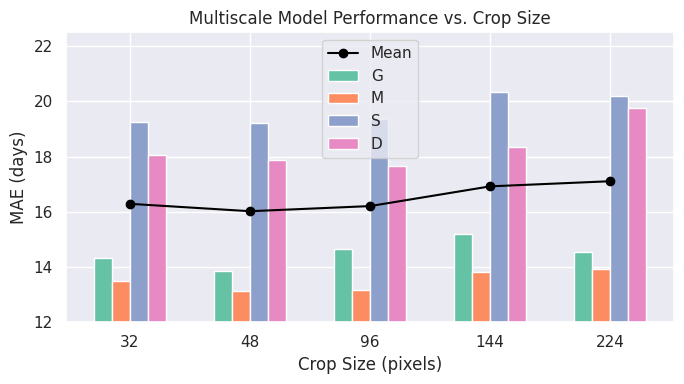

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Map crop sizes to their result keys (crop48 is the original without "crop" suffix)
crop_methods = {
    32:  "prithvi_pretrained_multiscale_crops_conv3d_crop32_1.0_test",
    48:  "prithvi_pretrained_multiscale_crops_conv3d_1.0_test",
    96:  "prithvi_pretrained_multiscale_crops_conv3d_crop96_1.0_test",
    144: "prithvi_pretrained_multiscale_crops_conv3d_crop144_1.0_test",
    224: "prithvi_pretrained_multiscale_crops_conv3d_crop224_1.0_test",
}

dates = ["G", "M", "S", "D"]
crop_sizes = sorted(crop_methods.keys())

# Compute mean MAE per date and overall for each crop size
mae_per_date = {d: [] for d in dates}
mae_mean = []

for cs in crop_sizes:
    key = crop_methods[cs]
    df_crop = results_mae_df[results_mae_df["Method"] == key]
    for d in dates:
        mae_per_date[d].append(df_crop[df_crop["Date"] == d]["MAE"].mean())
    mae_mean.append(df_crop["MAE"].mean())

# Plot
fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(crop_sizes))
width = 0.15
colors = sns.color_palette("Set2", 5)

for i, d in enumerate(dates):
    ax.bar(x + i * width, mae_per_date[d], width, label=d, color=colors[i])

# Mean line
ax.plot(x + 1.5 * width, mae_mean, marker='o', color='black', linewidth=1.5, label='Mean', zorder=5)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([str(cs) for cs in crop_sizes])
ax.set_xlabel("Crop Size (pixels)")
ax.set_ylabel("MAE (days)")
ax.set_title("Multiscale Model Performance vs. Crop Size")
ax.legend()
ax.set_ylim(12, 22.5)
plt.tight_layout()
plt.show()

## C- Does Prithvi have any advantges? 

We split performance per eco region. We note that: 

1- Prithvi performs substantially better on the North American Deserts region. 

2- This improvements disappears when the pretraining is absent highlighting its significance. 

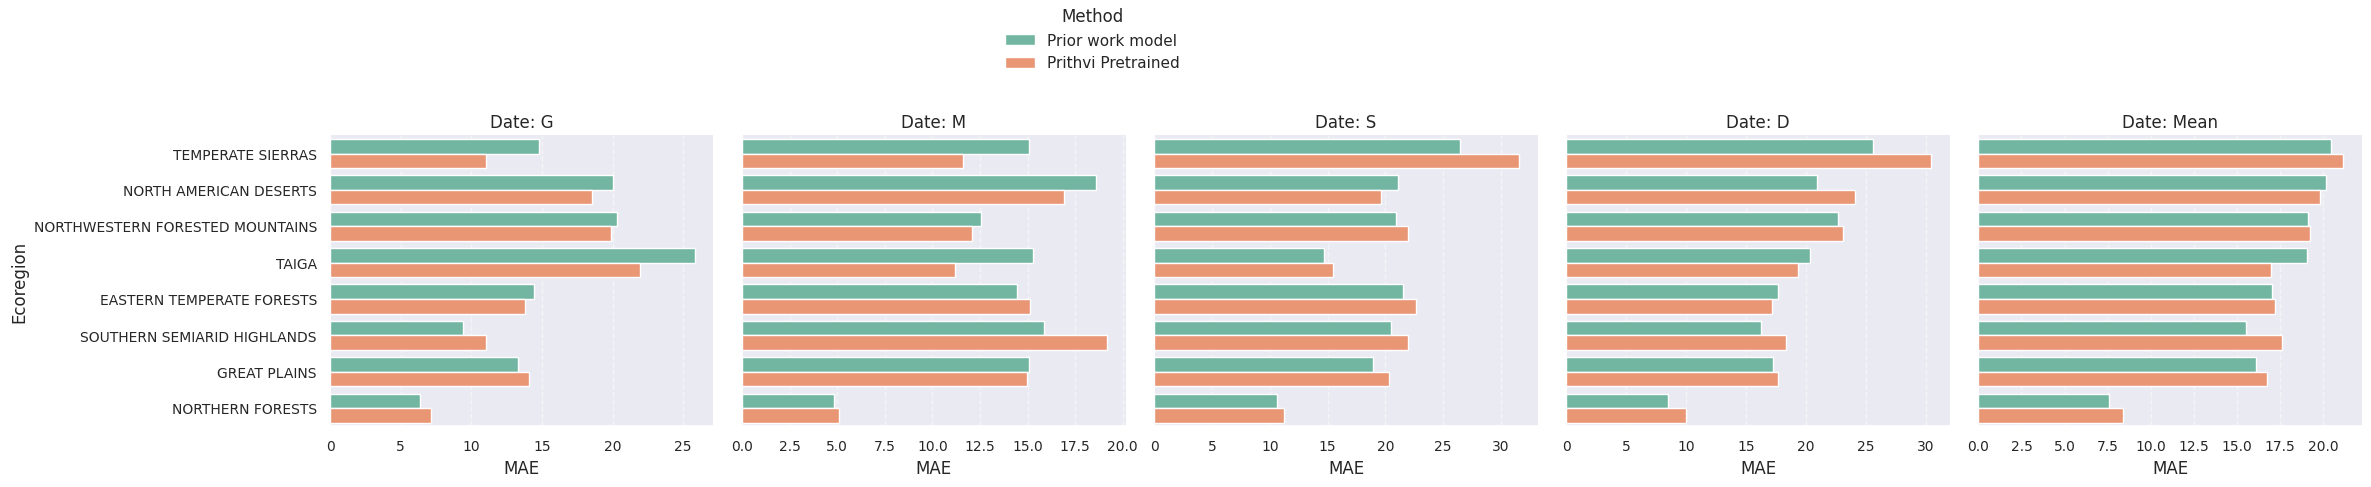

In [22]:
from lib.utils_plotting import plot_methods_regions_split

results_mae_df_ = results_mae_df.copy()
results_mae_df_["Method"] = results_mae_df_["Method"].replace("shallow_transformer_pixels_1.0_test", "Prior work model")
results_mae_df_["Method"] = results_mae_df_["Method"].replace("prithvi_pretrained_multiscale_crops_conv3d_1.0_test", "Prithvi Pretrained")

plot_methods_regions_split(results_mae_df_, 
                            geo_path=path_config.get_data_geojson(),
                            eco_path="useco1/NA_CEC_Eco_Level1.shp",
                            methods=["Prior work model", "Prithvi Pretrained"],
                         )

### D- Can we make use of this improved performance? 

We propose to use an Ensemble model that combines prior work shallow transformer and Prithvi outputs. Observe below that ensemble model significantly improves average performance, especially on north american deserts region. 

In [7]:
methods_to_print = ["shallow_transformer_pixels_1.0_test", 
                    "prithvi_pretrained_multiscale_crops_conv3d_1.0_test",
                    "prithvi_pretrained_crops_cathls_conv3d_1.0_test",
                    "prithvi_pretrained_crops_conv3d_1.0_test",
                    "Simple Ensemble prithvi_pretrained_multiscale_crops_conv3d_1.0, shallow_transformer_pixels_1.0",
                    "shallow_transformer_pixels_priorwork_data_test"]
avg_results = print_avg_results(methods_to_print, results_mae_df)

                                                                                                   G     M     S     D  Mean
Method                                                                                                                      
shallow_transformer_pixels_1.0_test                                                             14.5  13.5  18.8  17.5  16.1
prithvi_pretrained_multiscale_crops_conv3d_1.0_test                                             13.9  13.1  19.2  17.9  16.0
prithvi_pretrained_crops_cathls_conv3d_1.0_test                                                 14.1  12.9  19.0  17.1  15.8
prithvi_pretrained_crops_conv3d_1.0_test                                                        14.4  13.3  19.1  17.8  16.2
Simple Ensemble prithvi_pretrained_multiscale_crops_conv3d_1.0, shallow_transformer_pixels_1.0  13.4  12.6  18.3  16.8  15.3
shallow_transformer_pixels_priorwork_data_test                                                  13.4  10.7  16.6  15.4  14.0


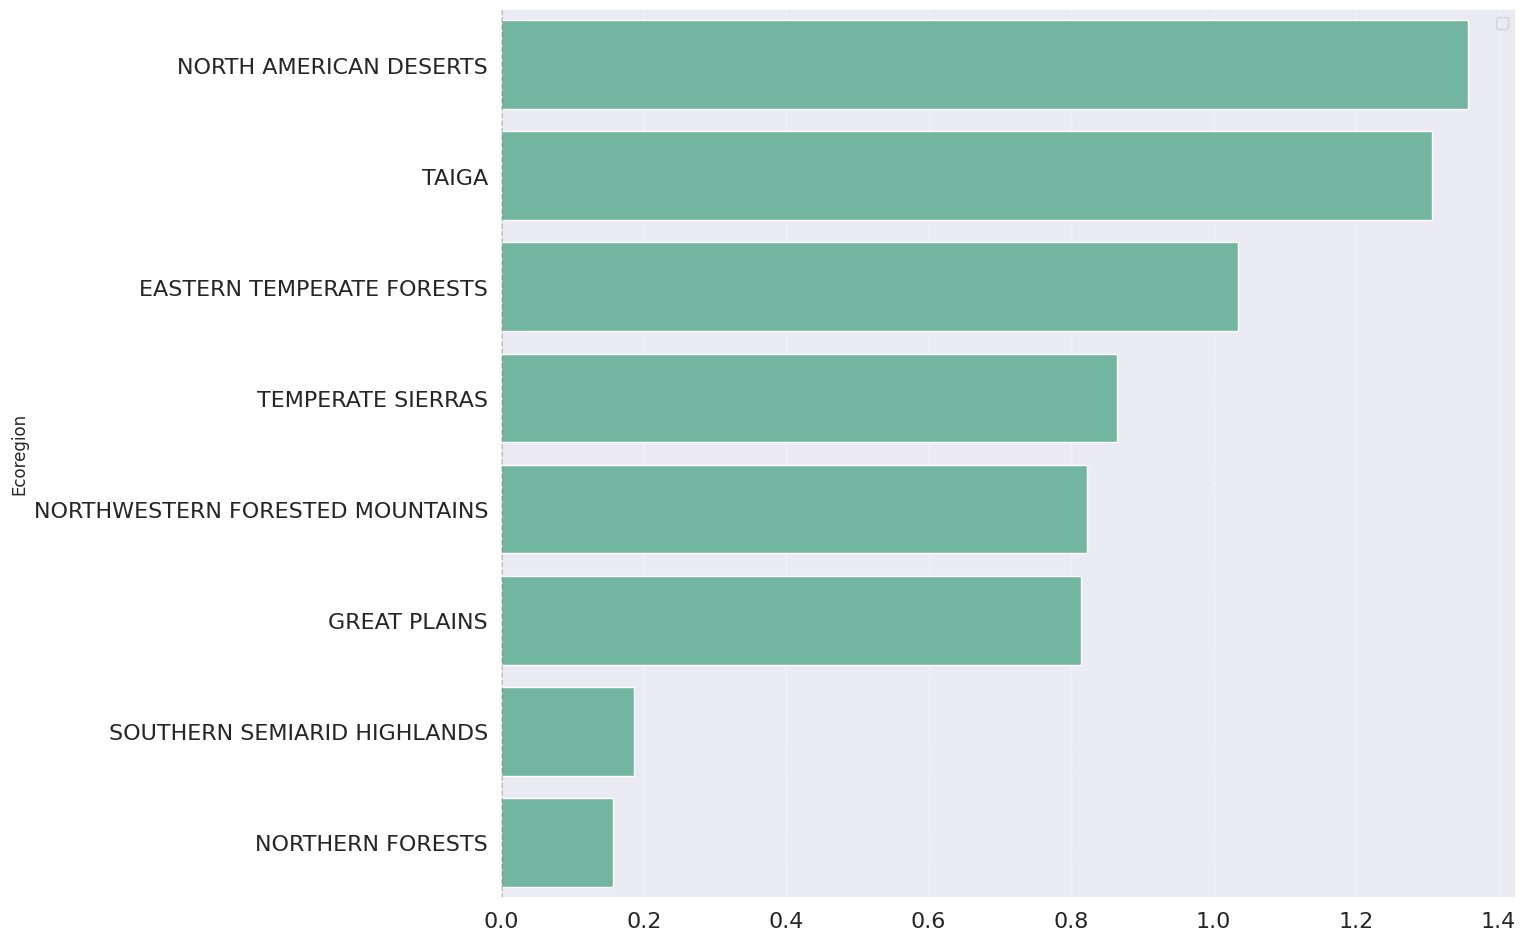

In [10]:
from lib.utils_plotting import plot_mae_improvement_by_region

results_mae_df_ = results_mae_df.copy()
plot_mae_improvement_by_region(
    results_mae_df_,
    geo_path=path_config.get_data_geojson(),
    eco_path="useco1/NA_CEC_Eco_Level1.shp",
    methods_to_compare=["Simple Ensemble prithvi_pretrained_multiscale_crops_conv3d_1.0, shallow_transformer_pixels_1.0"],
    anchor_method="shallow_transformer_pixels_1.0_test",
    figsize=(14, 10)
)

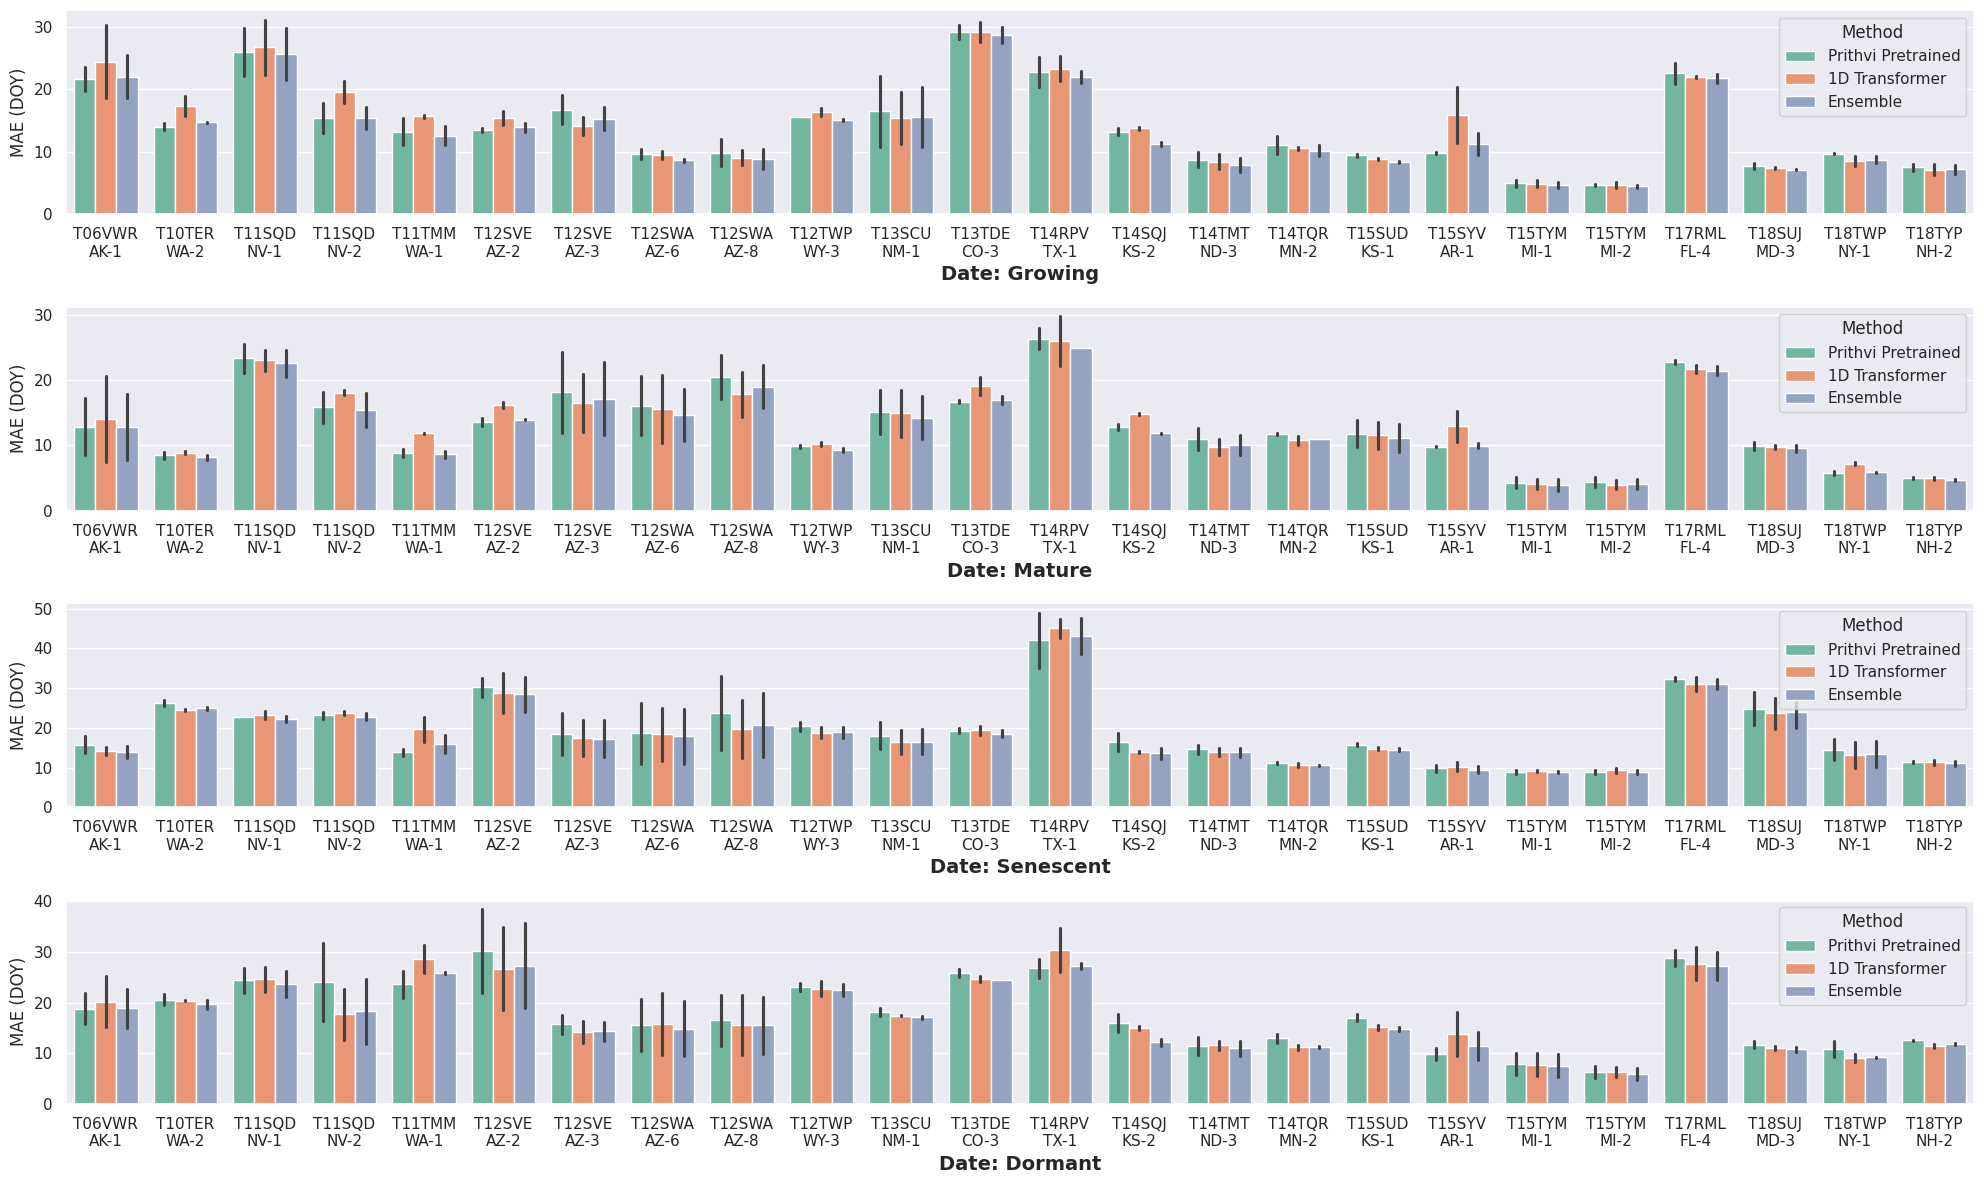

In [3]:
from lib.utils_plotting import plot_performance_tiles
results_mae_df_ = results_mae_df.copy()
results_mae_df_["Method"] = results_mae_df_["Method"].replace("shallow_transformer_pixels_1.0_test", "1D Transformer")
results_mae_df_["Method"] = results_mae_df_["Method"].replace("prithvi_pretrained_multiscale_crops_conv3d_1.0_test", "Prithvi Pretrained")
results_mae_df_["Method"] = results_mae_df_["Method"].replace("Simple Ensemble prithvi_pretrained_multiscale_crops_conv3d_1.0, shallow_transformer_pixels_1.0", "Ensemble")

plot_performance_tiles(results_mae_df_, methods= ["1D Transformer", 
                                                  "Prithvi Pretrained", 
                                                  "Ensemble"])